In [ ]:
# Use an LLM (chatgpt) to get a response using python code.
# Answer questions of user as if Budha would Answer
# def answer_like_buddha(question):
#   return str_answer

# Make it REPL (command line conversation chatbot)

You: 
Buddha: 

You:
Buddha: 




In [ ]:
# https://chatgpt.com/share/6a3606d5-7e38-83ea-8782-795d9b6f3bac

In [ ]:
# Make this prompt concise 

# 10 pager prompt -> 1 page. it is working better.


In [ ]:
# https://github.com/terno-ai/agentic/blob/main/agentic/core/agent.py#L478C5-L481C34

Take a look at agent loop


Q: One of the faults in this is if people are chatting for long. The context grows.

Q: This is not thread safe.
    take a look at this: 
        @app.route("/", methods=["GET", "POST"])
        def index():
            if "messages" not in session:
                session["messages"] = [
                    {"role": "system", "content": SYSTEM_PROMPT}
                ]


In [ ]:
# Q: Use chatgpt to build buddha as a react/django web app
# 

In [ ]:
# Q: How is a complex system like claude code able to handle so much of complexity ??
# A: Look at agentic. They basically call the LLM many number of times to get a problem solved.


In [ ]:
# Images:
#     1. Image -> convert into text. 
#      2. VQA
        # Image, Question -> Answer


In [ ]:
# We are building a chat bot that can answer user's questions on ICICI Bank Credit card.

SYSTEM_PROMPT: 
    Personality 
    Using their website.
    Upload documents

prompt:
    - You are customer support agent for ICICI bank credit cards. 
    - Here is the content from website: <<Download 50 pagest of website and convert it plain text>>
    - Here is are the addition documents: <<convert all .doc .pdf to text >>

Promblems:
    - The prompt overflow.

Solutions:
    - RAG:
        - System Prompt: 
            - You are customer support agent for ICICI bank credit cards. 
            - Here is the relavent document for users' question:
                    -- 2 pages relavent to user's question.

Q: How to find 2 pages that are relavent?
A: 
1. Convert users question-> vector and every page into a vector. Then do the matching.
    - 1. Word count based
    - 2. LLM based embedding (OPEN AI)
    - 3. Using LLM:
        Here is are the titles and the filnames of the various pages from customer support handbook. Suggest which pages might be relavent:
        credit limit.txt: this page talks about how the limit on credit card decided
     - 4. Use #2 to build a smaller list of documents/files. And use #3 to get the final files to attach.


Accuracy Wise:
    3 > 2 > 1

Cost / Time wise:
    1 > 2 > 3

Why is #1 (word count based) not good accuracy wise?
    - It does not handle synonyms
    - it doesn't handle the humour
    - it also does not differetiate between these two sentense:
        dog will eat chicken
        chicken will eat dog


In [6]:
from sklearn.datasets import fetch_20newsgroups
import random

# Load discussion forum messages
data = fetch_20newsgroups(
    subset="train",
    remove=()   # keep headers, footers, quotes
)

messages = data.data

# Pick 500 random messages
random_messages = random.sample(messages, 500)

# Print them
for i, msg in enumerate(random_messages, 1):
    print("=" * 80)
    print(f"Message {i}")
    print("=" * 80)
    print(msg)
    print()

Message 1
Subject: Automated X testing
From: mark@trident.datasys.swri.edu (Mark D. Collier)
Organization: Southwest Research Institute
Lines: 13

Does anyone know what is available in terms of automated testing
of X/Motif applications. I am thinking of a system which I could
program (or which could record events/output) with our verification
test procedures and then run/rerun each time we do regression
testing. I am interested in a product like this for our UNIX
projects and for a separate project which will be using OpenVMS.

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Mark D. Collier                      Southwest Research Institute
Senior Research Analyst              Automation and Data Systems Division
Voice: (512) 522-3437                Data Systems Department
FAX:   (512) 522-5499                Software Engineering Section
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


Message 2
From: prb@access.digex.com (Pat)
Subjec


# Exercise: 

Pick 1000 messages from fetch_20newsgroups. Remove all special characters. Convert each message into a vector as shown below.

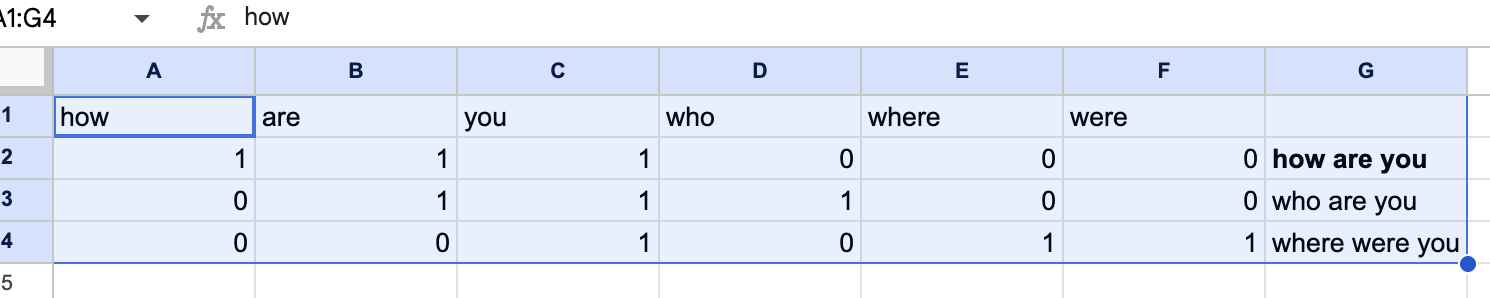

In [ ]:
# Are embedding matching the answer or the questions?

A. "The capital of India"
B. "The capital of Pakistan"
C. "Delhi"
D. "The first word of a movie by Amir khan of which the second word is belly"

In [6]:
OPENAI_API_KEY = open('.openai_key').read().strip()

In [ ]:
from openai import OpenAI
import numpy as np
from itertools import combinations

client = OpenAI(api_key=OPENAI_API_KEY)

sentences = [
    "The first word of a movie by Amir khan of which the second word is belly",
    "The capital of India in one word. Just one word nothing else",
    "The captial of Pakistan in one word. Just one word nothing else"
]

# Generate embeddings
response = client.embeddings.create(
    model="text-embedding-3-small",
    input=sentences
)

embeddings = [np.array(item.embedding) for item in response.data]

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Compare every pair
for i, j in combinations(range(len(sentences)), 2):
    sim = cosine_similarity(embeddings[i], embeddings[j])
    print(f"\nSentence {i+1}: {sentences[i]}")
    print(f"Sentence {j+1}: {sentences[j]}")
    print(f"Cosine Similarity: {sim:.4f}")



Sentence 1: The captial of Bharat desh
Sentence 2: The capital of India in one word. Just one word nothing else
Cosine Similarity: 0.5823

Sentence 1: The captial of Bharat desh
Sentence 3: The captial of Pakistan in one word. Just one word nothing else
Cosine Similarity: 0.4603

Sentence 2: The capital of India in one word. Just one word nothing else
Sentence 3: The captial of Pakistan in one word. Just one word nothing else
Cosine Similarity: 0.7832


In [15]:
sentences = [
    "The capital of Hindustan",
    "The capital of India ",
    "The captial of Pakistan "
]

# Generate embeddings
response = client.embeddings.create(
    model="text-embedding-3-small",
    input=sentences
)

embeddings = [np.array(item.embedding) for item in response.data]
# Compare every pair
for i, j in combinations(range(len(sentences)), 2):
    sim = cosine_similarity(embeddings[i], embeddings[j])
    print(f"\nSentence {i+1}: {sentences[i]}")
    print(f"Sentence {j+1}: {sentences[j]}")
    print(f"Cosine Similarity: {sim:.4f}")



Sentence 1: The capital of Hindustan
Sentence 2: The capital of India 
Cosine Similarity: 0.7572

Sentence 1: The capital of Hindustan
Sentence 3: The captial of Pakistan 
Cosine Similarity: 0.5582

Sentence 2: The capital of India 
Sentence 3: The captial of Pakistan 
Cosine Similarity: 0.6106


In [ ]:
User -> Question -> We find relavent content to user's question -> ask LLM to synthesize.

In [ ]:
# Agentic Harness

Prompt = '''

Answer the user's question. 

User's Question: What are the credit card limits?

Here is the list of documents:
file1.txt: COntains the credit card limit details of the corporate users.
file2.txt: contains the credit card limits and conditions of the individual users.
file3.txt: contains the terms and conditions for approval of credit card.

You can do one of the following things. 
    1. ANswer the user's question. In this case, start the line with 
    ANSWER: <the answer to user's question>

    2. Ask user clarification question. In this case, the format would be:
    ASKUSER: <is your account corporate?>

    3. Read a file. If you need a file to be read in order to answer users question.
    READFILE: <filename.txt>

'''

In [ ]:
DOCUMENTS = {
    "file1.txt": "Corporate users have credit card limits between 10000-50000 based on company approval.",
    "file2.txt": "Individual users have limits between 2000-5000 based on the credit score.",
    "file3.txt": "Credit card approval depends on KYC, income proof, credit score, and risk checks."
}

SYSTEM_PROMPT = """
Answer the user's question.

User's Question: {user_question}

Here is the list of documents:
{DOCUMENTS}

You can do one of the following things:

1. Answer the user's question:
ANSWER: <answer>

2. Ask user a clarification question:
ASKUSER: <question>

3. Read a file:
READFILE: <filename.txt>
"""

def call_llm(prompt: str) -> str:
    """
    Replace this with OpenAI / Anthropic / local LLM call.
    """
    raise NotImplementedError


def parse_action(response: str):
    response = response.strip()

    if response.startswith("ANSWER:"):
        return "ANSWER", response[len("ANSWER:"):].strip()

    if response.startswith("ASKUSER:"):
        return "ASKUSER", response[len("ASKUSER:"):].strip()

    if response.startswith("READFILE:"):
        return "READFILE", response[len("READFILE:"):].strip()

    return "INVALID", response


def agentic_harness(user_question: str):
    conversation_context = ""

    while True:
        prompt = SYSTEM_PROMPT.format(user_question=user_question, DOCUMENTS=DOCUMENTS)

        if conversation_context:
            prompt += "\n\nAdditional context:\n" + conversation_context

        llm_response = call_llm(prompt)
        action, value = parse_action(llm_response)

        if action == "ANSWER":
            return value

        elif action == "ASKUSER":
            user_reply = input(value + "\nUser: ")
            conversation_context += f"\nClarification asked: {value}"
            conversation_context += f"\nUser replied: {user_reply}"

        elif action == "READFILE":
            filename = value

            if filename not in DOCUMENTS:
                conversation_context += f"\nError: File {filename} does not exist."
            else:
                file_content = DOCUMENTS[filename]
                conversation_context += f"\nContent of {filename}:\n{file_content}"

        else:
            conversation_context += f"""
The previous response was invalid:
{value}

Please respond only in one of these formats:
ANSWER: ...
ASKUSER: ...
READFILE: filename.txt
"""

In [16]:
# https://chatgpt.com/share/6a3772fd-2034-83ea-85a9-9a60063743c6

In [ ]:
TokenPredictor: next token 

AnswerPredictor: (calls TokenPredictor multiple times)

Agentic Harness: (call AnswerPredictor mutliple times.)

In [ ]:
# Exercise: 
    - Give this agent, python code execution tool. And run the python code after asking user's permission.



In [ ]:
# Gemini

Question -> Answer -> Verify -> loop back